# How Does CNN Depth Affect Feature Learning? A Comparative Study of Shallow, Medium and Deep Networks on CIFAR-10

## Repository

The full code and materials for this project are available on GitHub:

GitHub: https://github.com/MaheshGollapelli-24165281/cnn-depth-analysis


## Introduction

Convolutional Neural Networks (CNNs) are widely used in computer vision tasks due to their ability to automatically learn hierarchical representations from image data.

This project investigates how CNN depth influences feature learning by comparing shallow, medium, and deep CNN architectures using the CIFAR-10 dataset.

The objectives are:

- to compare CNN architectures with different depths  
- to analyse classification performance and generalisation  
- to visualise feature maps across layers  
- to understand how increasing network depth affects feature learning and representation  

## Reproducibility

To reproduce this work, install the required libraries listed in the requirements file and run the notebook from top to bottom.

Random seeds were set to improve consistency.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Print versions
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


TensorFlow version: 2.21.0
NumPy version: 2.4.3


## Dataset Description

The CIFAR-10 dataset contains 60,000 images across 10 classes such as airplanes, cars, and animals. The images are low resolution (32×32), making classification challenging and requiring effective feature extraction.

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Flatten labels once so later code is cleaner
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

C:\Users\MAHESH GOLLAPELLI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


## Sample Images

These sample images from the CIFAR-10 dataset illustrate the diversity and low resolution of the input data. This makes the task challenging and requires the model to learn robust features.

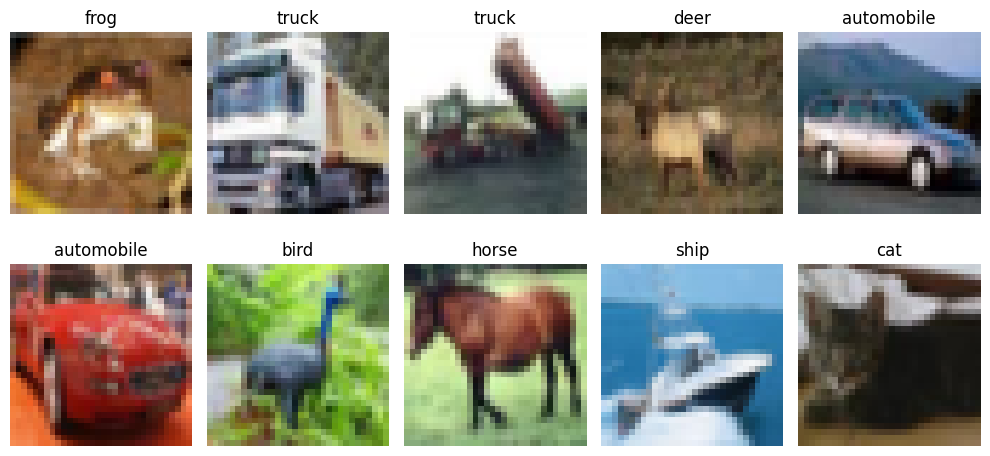

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

### Dataset Overview

These sample images from the CIFAR-10 dataset illustrate the diversity and low resolution of the input data. This makes the task challenging and requires the model to learn robust features.

## Accessibility

This notebook uses clear headings, labelled figures, and written explanations. Visual outputs are supported by textual descriptions to ensure accessibility.

## Data Preprocessing

Before training, the image data is normalised by scaling pixel values to the range [0, 1]. This helps stabilise optimisation and improves learning behaviour.

The class labels are also converted to one-hot encoded vectors, which are required for multi-class classification using categorical cross-entropy loss.

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Training data range:", x_train.min(), "to", x_train.max())
print("One-hot label shape:", y_train_cat.shape)

Training data range: 0.0 to 1.0
One-hot label shape: (50000, 10)


## Model Design

Three different CNN architectures are used in this study to analyse the effect of network depth.

### Shallow CNN
The shallow network contains fewer convolutional layers. It is expected to learn lower-level image features such as edges and simple textures.

### Medium CNN
The medium network contains more convolutional layers than the shallow model. It is designed to capture intermediate feature representations, combining simple patterns into more structured forms.

### Deep CNN
The deep network contains the highest number of convolutional layers. With greater depth, it is able to form richer feature hierarchies and learn more abstract and complex patterns.

All three models are trained on the same data using identical training settings, ensuring that network depth is the main factor under investigation.

In [5]:
def build_shallow_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential(name="Shallow_CNN")
    
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="shallow_conv1"))
    model.add(layers.MaxPooling2D((2, 2), name="shallow_pool1"))
    
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="shallow_conv2"))
    model.add(layers.MaxPooling2D((2, 2), name="shallow_pool2"))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu", name="shallow_dense1"))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation="softmax", name="shallow_output"))
    
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

shallow_model = build_shallow_cnn()
shallow_model.summary()

Model: "Shallow_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ shallow_conv1 (Conv2D)               │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ shallow_pool1 (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ shallow_conv2 (Conv2D)               │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ shallow_pool2 (MaxPooling2D)         │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ shallow_dense1 (Dense)               │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ shallow_output (Dense)               │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
def build_medium_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential(name="Medium_CNN")

    model.add(layers.Input(shape=input_shape))

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="medium_conv1"))
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="medium_conv2"))
    model.add(layers.MaxPooling2D((2, 2), name="medium_pool1"))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="medium_conv3"))
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="medium_conv4"))
    model.add(layers.MaxPooling2D((2, 2), name="medium_pool2"))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu", name="medium_dense1"))
    model.add(layers.Dropout(0.35))
    model.add(layers.Dense(num_classes, activation="softmax", name="medium_output"))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

medium_model = build_medium_cnn()
medium_model.summary()

Model: "Medium_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ medium_conv1 (Conv2D)                │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ medium_conv2 (Conv2D)                │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ medium_pool1 (MaxPooling2D)          │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ medium_conv3 (Conv2D)                │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ medium_conv4 (Conv2D)                │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ medium_pool2 (MaxPooling2D)          │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ medium_dense1 (Dense)                │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ medium_output (Dense)                │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
def build_deep_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential(name="Deep_CNN")
    
    model.add(layers.Input(shape=input_shape))
    
    # Block 1
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="deep_conv1"))
    model.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="deep_conv2"))
    model.add(layers.MaxPooling2D((2, 2), name="deep_pool1"))
    
    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="deep_conv3"))
    model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="deep_conv4"))
    model.add(layers.MaxPooling2D((2, 2), name="deep_pool2"))
    
    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="deep_conv5"))
    model.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="deep_conv6"))
    model.add(layers.MaxPooling2D((2, 2), name="deep_pool3"))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation="relu", name="deep_dense1"))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(num_classes, activation="softmax", name="deep_output"))
    
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

deep_model = build_deep_cnn()
deep_model.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ deep_conv1 (Conv2D)                  │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_conv2 (Conv2D)                  │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_pool1 (MaxPooling2D)            │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_conv3 (Conv2D)                  │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_conv4 (Conv2D)                  │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_pool2 (MaxPooling2D)            │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_conv5 (Conv2D)                  │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_conv6 (Conv2D)                  │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_pool3 (MaxPooling2D)            │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_dense1 (Dense)                  │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ deep_output (Dense)                  │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

## Training Procedure

All three CNN models (shallow, medium, and deep) are trained using the same dataset and identical training settings, including optimiser, loss function, batch size, number of epochs, and validation split. This ensures that any differences in performance can be attributed primarily to network depth rather than variations in training conditions.

Validation performance is monitored throughout training to evaluate how well each model generalises beyond the training data.

The comparison focuses on:

- training accuracy  
- validation accuracy  
- training loss  
- validation loss  

This allows for a detailed analysis of how increasing network depth influences learning behaviour, convergence speed, and generalisation performance.

In [8]:
epochs = 8
batch_size = 64

history_shallow = shallow_model.fit(
    x_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

history_medium = medium_model.fit(
    x_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

history_deep = deep_model.fit(
    x_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4045 - loss: 1.6349 - val_accuracy: 0.5282 - val_loss: 1.3256
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5407 - loss: 1.2878 - val_accuracy: 0.5867 - val_loss: 1.1611
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5967 - loss: 1.1352 - val_accuracy: 0.6391 - val_loss: 1.0368
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6339 - loss: 1.0368 - val_accuracy: 0.6574 - val_loss: 0.9802
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6572 - loss: 0.9696 - val_accuracy: 0.6674 - val_loss: 0.9542
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6795 - loss: 0.9024 - val_accuracy: 0.6707 - val_loss: 0.9544
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6985 - loss: 0.8540 - val_accuracy: 0.6806 - val_loss: 0.9278
Epoch 8/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7109 - loss: 0.8109 - val_accu

### Accuracy Curves

All three models were trained using the same optimiser, loss function, batch size, epoch count, and validation split. This ensures that any differences in performance are mainly due to network depth rather than changes in training settings.

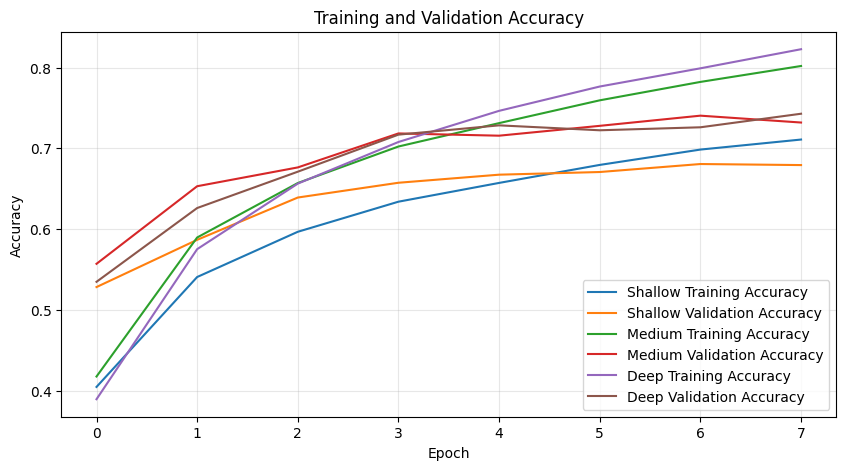

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history_shallow.history["accuracy"], label="Shallow Training Accuracy")
plt.plot(history_shallow.history["val_accuracy"], label="Shallow Validation Accuracy")

plt.plot(history_medium.history["accuracy"], label="Medium Training Accuracy")
plt.plot(history_medium.history["val_accuracy"], label="Medium Validation Accuracy")

plt.plot(history_deep.history["accuracy"], label="Deep Training Accuracy")
plt.plot(history_deep.history["val_accuracy"], label="Deep Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Loss Curves

Loss curves provide additional insight into the optimisation process. Lower loss indicates that the model's predictions are becoming closer to the true labels.

Comparing the shallow, medium, and deep CNNs shows how increasing network depth affects learning behaviour. The medium and deep models achieve lower loss values and converge more effectively than the shallow model, indicating stronger learning capacity.

However, deeper models may also show a gap between training and validation loss in later epochs, suggesting mild overfitting. This highlights the trade-off between improved performance and generalisation as network depth increases.

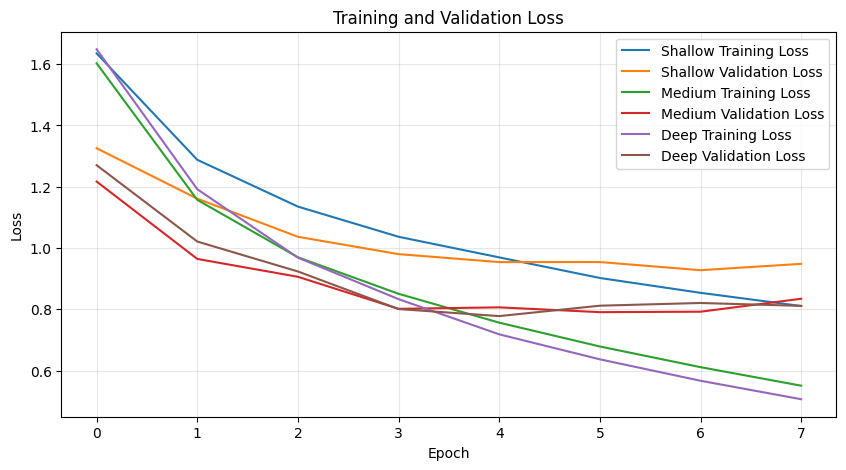

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(history_shallow.history["loss"], label="Shallow Training Loss")
plt.plot(history_shallow.history["val_loss"], label="Shallow Validation Loss")

plt.plot(history_medium.history["loss"], label="Medium Training Loss")
plt.plot(history_medium.history["val_loss"], label="Medium Validation Loss")

plt.plot(history_deep.history["loss"], label="Deep Training Loss")
plt.plot(history_deep.history["val_loss"], label="Deep Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Test Set Evaluation

After training, all three models (shallow, medium, and deep CNNs) are evaluated on the unseen test set. Test accuracy provides a fair comparison of how well each network generalises to new data.

This is important because a model that performs well only on training data may not learn robust feature representations or generalise effectively. Comparing all three models also helps reveal how increasing network depth impacts generalisation performance.

In [11]:
test_loss_shallow, test_acc_shallow = shallow_model.evaluate(x_test, y_test_cat, verbose=0)
test_loss_medium, test_acc_medium = medium_model.evaluate(x_test, y_test_cat, verbose=0)
test_loss_deep, test_acc_deep = deep_model.evaluate(x_test, y_test_cat, verbose=0)

print(f"Shallow CNN Test Accuracy: {test_acc_shallow:.4f}")
print(f"Shallow CNN Test Loss:     {test_loss_shallow:.4f}")
print("-" * 40)
print(f"Medium CNN Test Accuracy:  {test_acc_medium:.4f}")
print(f"Medium CNN Test Loss:      {test_loss_medium:.4f}")
print("-" * 40)
print(f"Deep CNN Test Accuracy:    {test_acc_deep:.4f}")
print(f"Deep CNN Test Loss:        {test_loss_deep:.4f}")

Shallow CNN Test Accuracy: 0.6696
Shallow CNN Test Loss:     0.9611
----------------------------------------
Medium CNN Test Accuracy:  0.7301
Medium CNN Test Loss:      0.8603
----------------------------------------
Deep CNN Test Accuracy:    0.7391
Deep CNN Test Loss:        0.8287


## Accuracy Comparison

The bar chart below provides a direct visual comparison of the final test accuracy across the shallow, medium, and deep CNN models. It highlights how performance improves as network depth increases, with the medium model showing intermediate performance between the shallow and deep architectures.

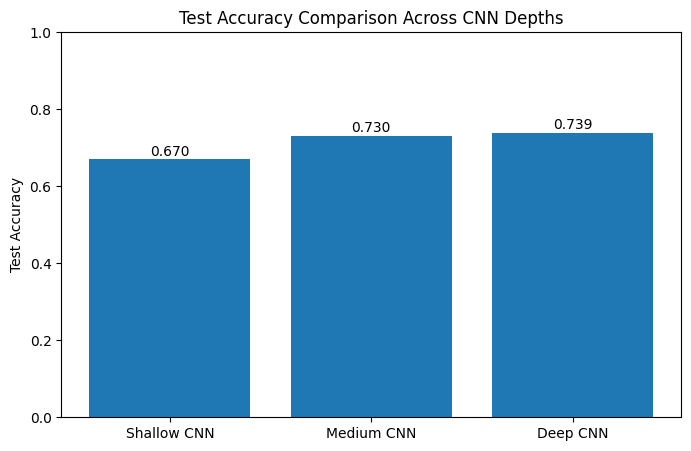

In [12]:
model_names = ["Shallow CNN", "Medium CNN", "Deep CNN"]
accuracies = [test_acc_shallow, test_acc_medium, test_acc_deep]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies)
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison Across CNN Depths")

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.01, f"{acc:.3f}", ha="center")

plt.show()

## Predictions and Classification Behaviour

To better understand model behaviour, predictions are generated for the test set. This allows a closer inspection of where the models perform well and where confusion between classes may occur.

In [13]:
y_pred_shallow = np.argmax(shallow_model.predict(x_test, verbose=0), axis=1)
y_pred_medium = np.argmax(medium_model.predict(x_test, verbose=0), axis=1)
y_pred_deep = np.argmax(deep_model.predict(x_test, verbose=0), axis=1)

## Confusion Matrix Analysis

The confusion matrix for the deep model provides a class-by-class view of performance. It highlights which categories are recognised well and which are more difficult to separate.

This is useful because overall accuracy alone does not show which classes are being confused.

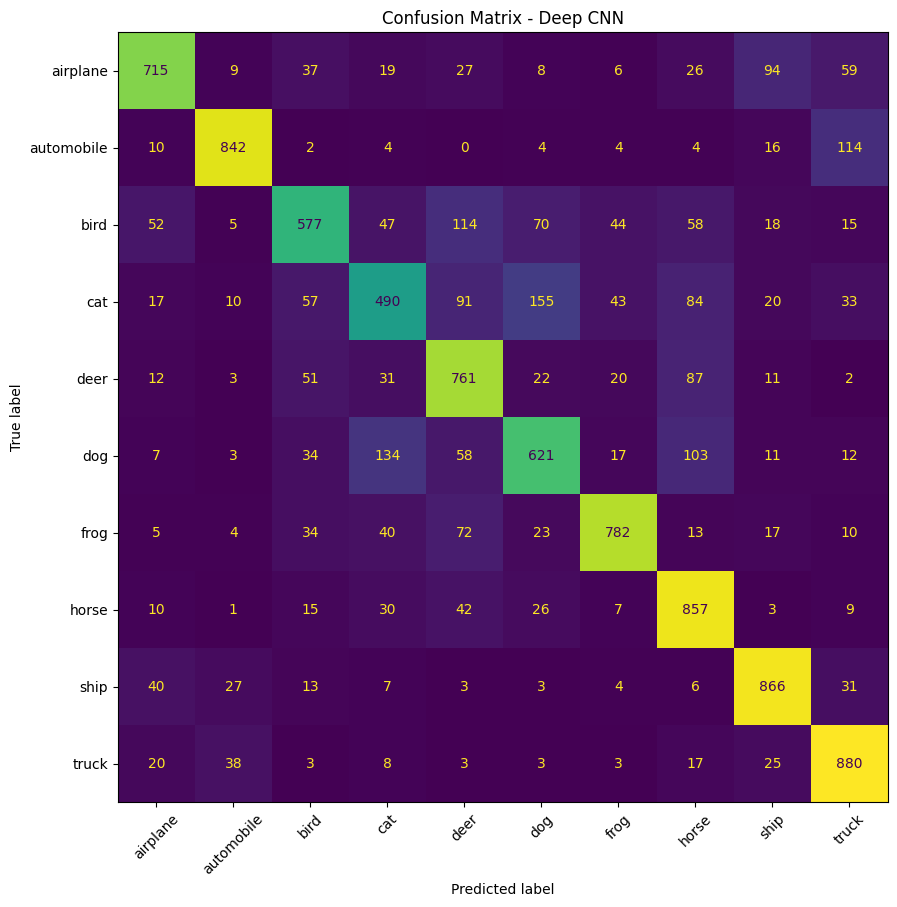

In [14]:
cm = confusion_matrix(y_test, y_pred_deep)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - Deep CNN")
plt.show()

The confusion matrix shows that the model performs well on distinct classes such as ships and frogs, but struggles with visually similar classes like cats and dogs. This highlights the importance of feature learning depth.

## Classification Report

The classification report includes precision, recall, and F1-score for each class. These metrics provide a more detailed evaluation than accuracy alone and help identify class-specific strengths and weaknesses.

In [15]:
print("Classification Report - Deep CNN")
print(classification_report(y_test, y_pred_deep, target_names=class_names))

Classification Report - Deep CNN
              precision    recall  f1-score   support

    airplane       0.81      0.71      0.76      1000
  automobile       0.89      0.84      0.87      1000
        bird       0.70      0.58      0.63      1000
         cat       0.60      0.49      0.54      1000
        deer       0.65      0.76      0.70      1000
         dog       0.66      0.62      0.64      1000
        frog       0.84      0.78      0.81      1000
       horse       0.68      0.86      0.76      1000
        ship       0.80      0.87      0.83      1000
       truck       0.76      0.88      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



## Sample Predictions

The images below show sample predictions from both models. Comparing the two outputs helps illustrate whether the deeper CNN makes more accurate or more stable decisions on unseen examples.

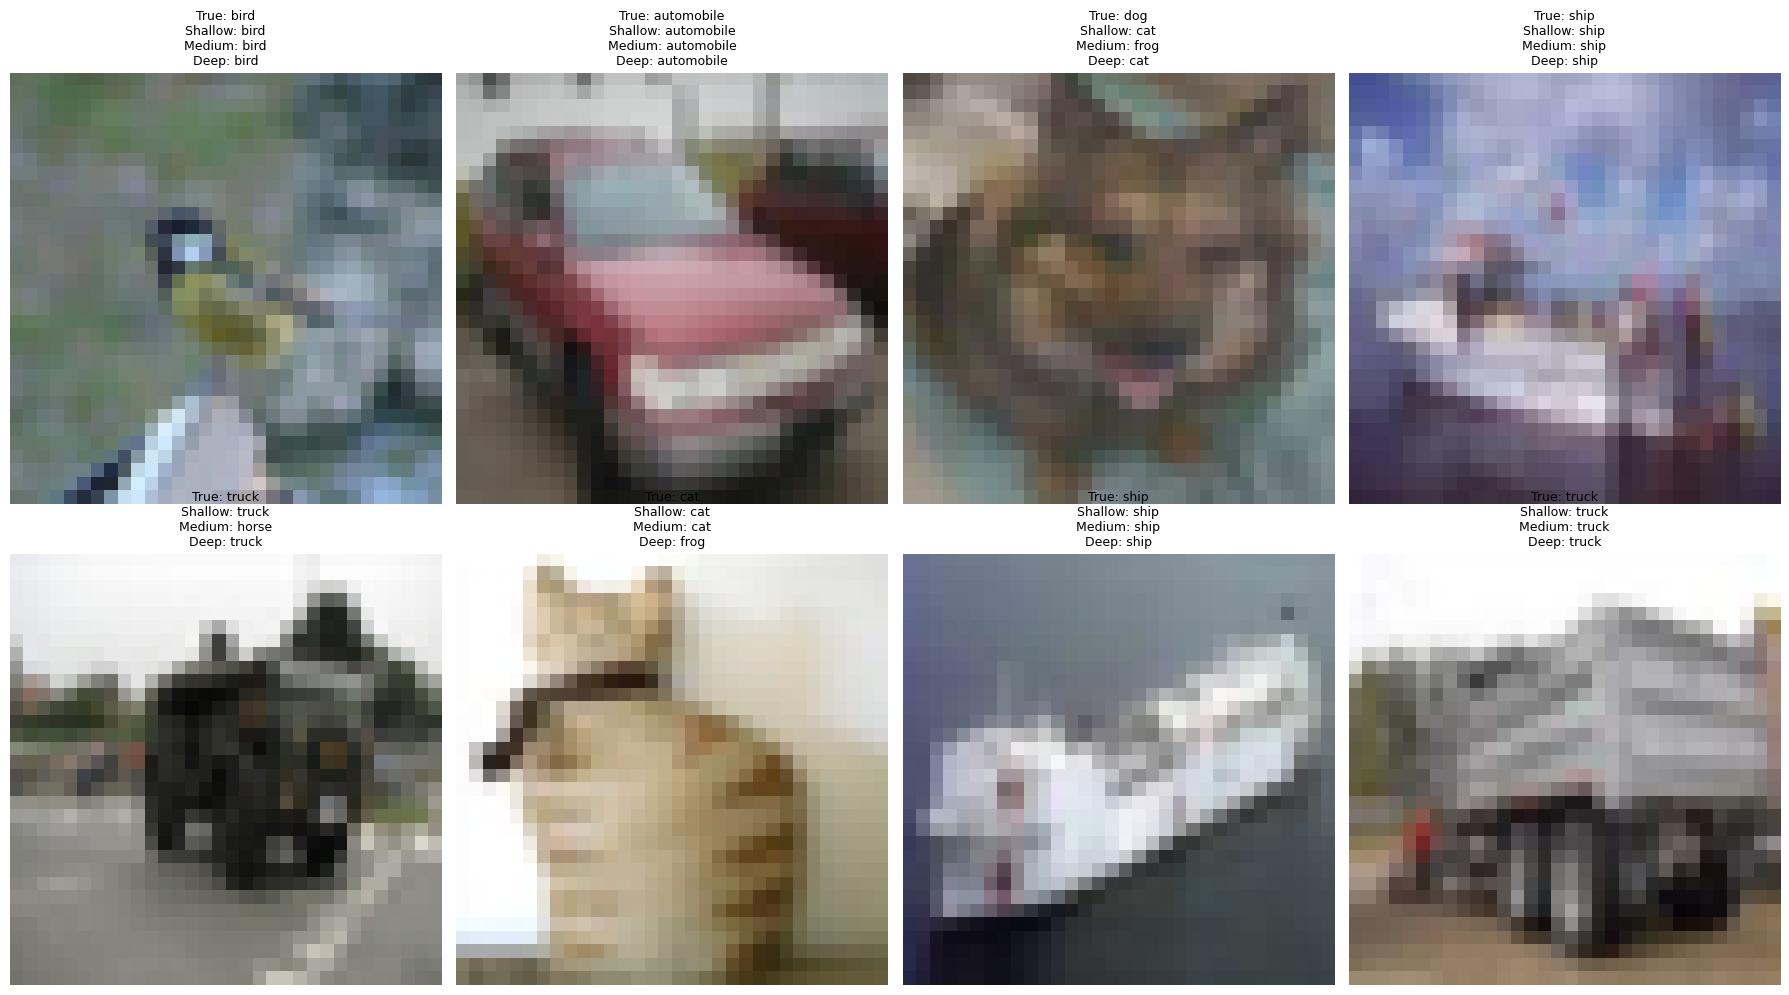

In [16]:
def show_predictions(images, true_labels, pred1, pred2, pred3, class_names, n=8):
    plt.figure(figsize=(18, 10))
    indices = np.random.choice(len(images), n, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[idx])
        true_class = class_names[int(true_labels[idx])]
        pred_class_1 = class_names[int(pred1[idx])]
        pred_class_2 = class_names[int(pred2[idx])]
        pred_class_3 = class_names[int(pred3[idx])]
        plt.title(
            f"True: {true_class}\n"
            f"Shallow: {pred_class_1}\n"
            f"Medium: {pred_class_2}\n"
            f"Deep: {pred_class_3}",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(
    (x_test * 255).astype("uint8"),
    y_test,
    y_pred_shallow,
    y_pred_medium,
    y_pred_deep,
    class_names
)

## Feature Map Visualisation

A key objective of this project is to understand how CNN depth shapes feature learning. Feature maps reveal how different convolutional layers respond to an input image.

In general:

- earlier layers respond to simple visual patterns such as edges and corners  
- intermediate layers detect textures and repeated structures  
- deeper layers capture more abstract and task-relevant patterns  

By visualising activations across the shallow, medium, and deep CNNs, it becomes possible to examine how feature complexity increases with depth, even when processing the same input image.

In [17]:
def get_feature_maps(model, image, layer_names):
    # Force model to build (important fix)
    _ = model.predict(np.expand_dims(image, axis=0), verbose=0)

    outputs = [model.get_layer(name).output for name in layer_names]
    activation_model = tf.keras.Model(inputs=model.inputs, outputs=outputs)
    activations = activation_model.predict(np.expand_dims(image, axis=0), verbose=0)
    return activations

def plot_feature_maps(activations, layer_names, max_maps=6):
    for activation, layer_name in zip(activations, layer_names):
        num_filters = min(activation.shape[-1], max_maps)

        plt.figure(figsize=(12, 4))
        for i in range(num_filters):
            plt.subplot(1, num_filters, i + 1)
            plt.imshow(activation[0, :, :, i], cmap="viridis")
            plt.title(f"{layer_name}\nMap {i+1}", fontsize=9)
            plt.axis("off")

        plt.suptitle(f"Feature Maps from {layer_name}", fontsize=12)
        plt.tight_layout()
        plt.show()

## Input Image for Feature Analysis

One test image is selected as an example input. Its feature maps are then visualised at different depths of each network to compare how representations evolve.

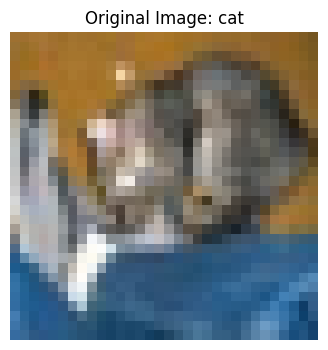

In [18]:
sample_index = 0
sample_image = x_test[sample_index]

# If y_test has shape (10000, 1), use int(...)
sample_label = class_names[int(y_test[sample_index])]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Original Image: {sample_label}")
plt.axis("off")
plt.show()

## Feature Maps from the Shallow CNN

The feature maps below show how the shallow network responds to the selected input image. Because the model contains fewer convolutional layers, it is expected to focus more strongly on lower-level image structures.

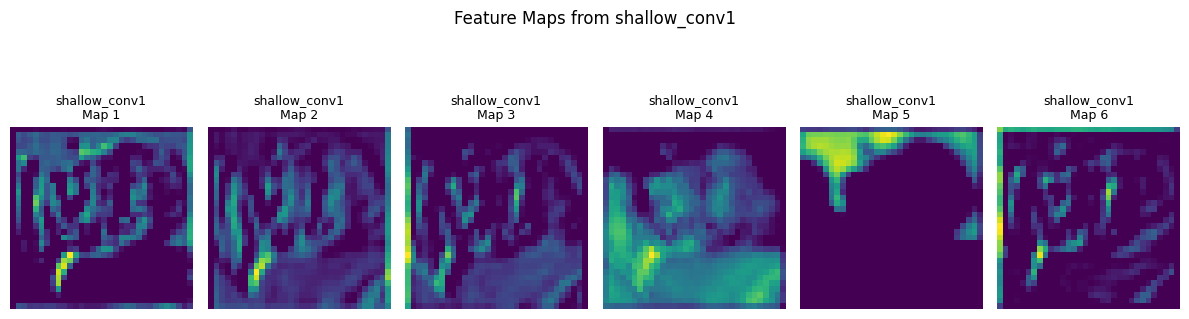

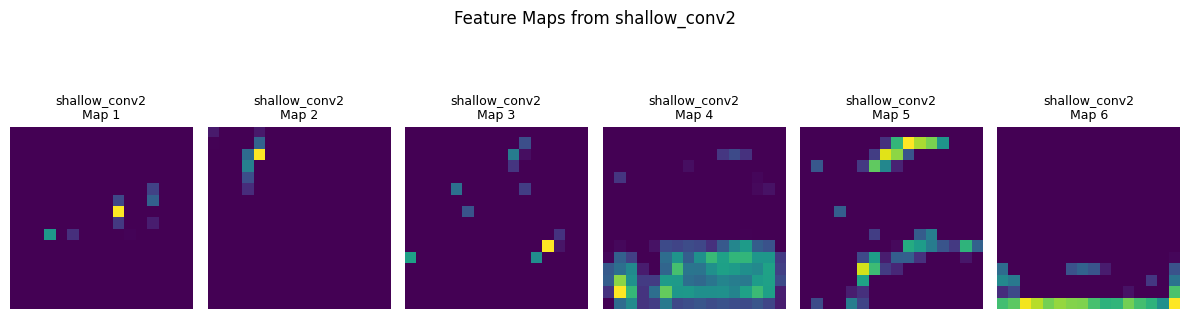

In [19]:
shallow_layers_to_view = ["shallow_conv1", "shallow_conv2"]

shallow_activations = get_feature_maps(shallow_model, sample_image, shallow_layers_to_view)
plot_feature_maps(shallow_activations, shallow_layers_to_view, max_maps=6)

### Feature Maps from the Medium CNN

The medium-depth network contains more convolutional layers than the shallow model, allowing it to capture more structured and refined feature representations. Its feature maps show an intermediate level of complexity, where simple edges and textures begin to combine into more meaningful patterns.

This demonstrates how increasing depth enhances feature learning step by step, with the medium CNN acting as a bridge between basic low-level features and the more abstract representations learned by the deep network.

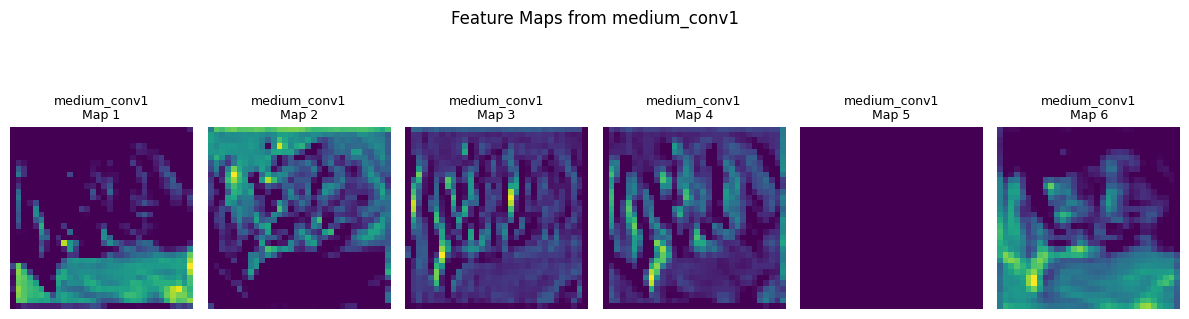

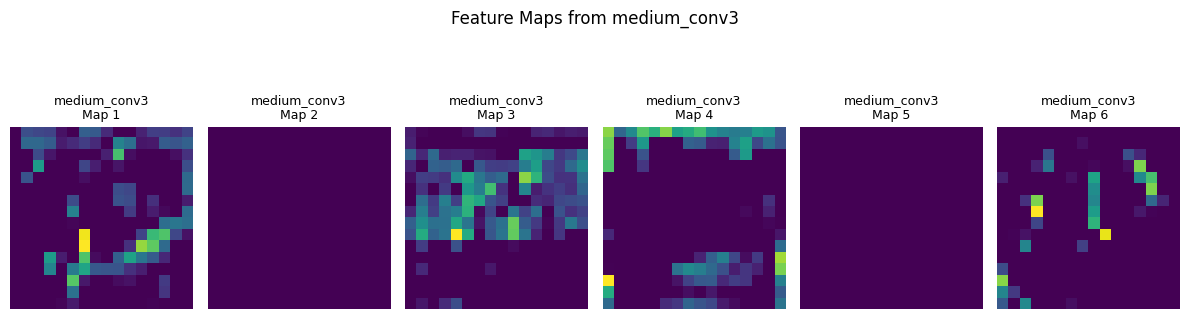

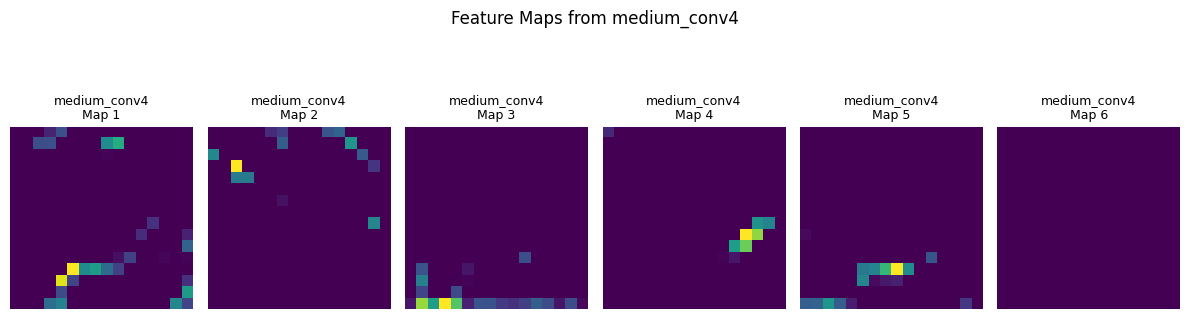

In [20]:
medium_layers_to_view = ["medium_conv1", "medium_conv3", "medium_conv4"]

medium_activations = get_feature_maps(medium_model, sample_image, medium_layers_to_view)
plot_feature_maps(medium_activations, medium_layers_to_view, max_maps=6)

## Feature Maps from the Deep CNN

The deeper network contains more convolutional stages, so its later feature maps are expected to reflect more selective and abstract responses. This helps illustrate how depth contributes to hierarchical feature learning.

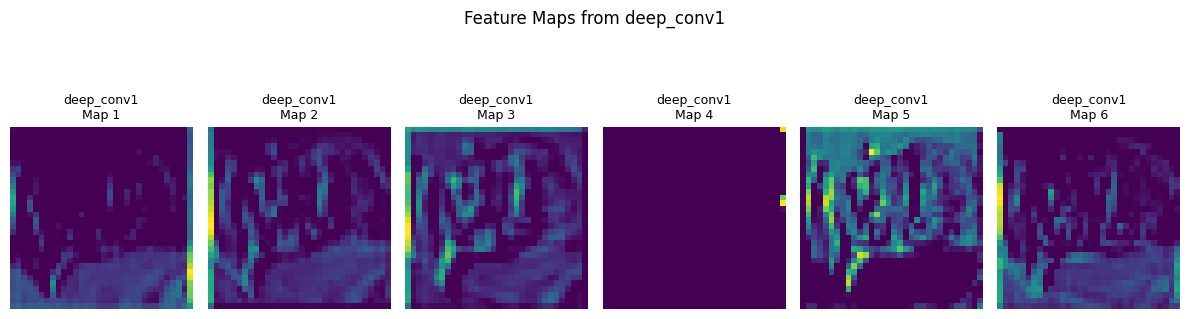

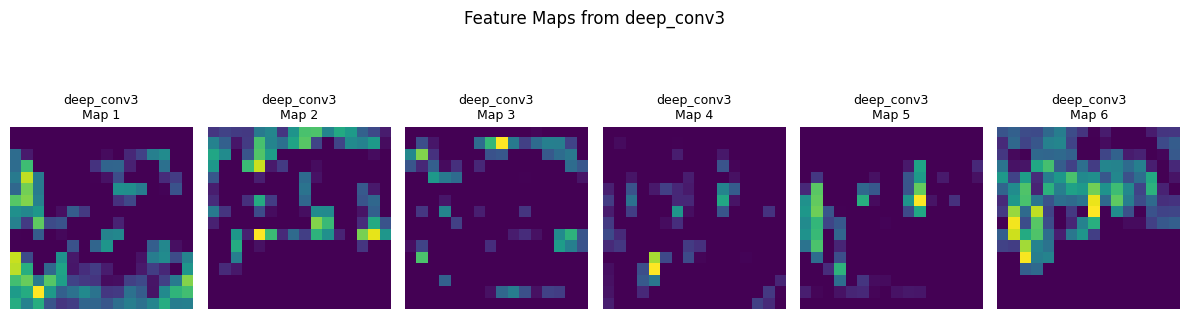

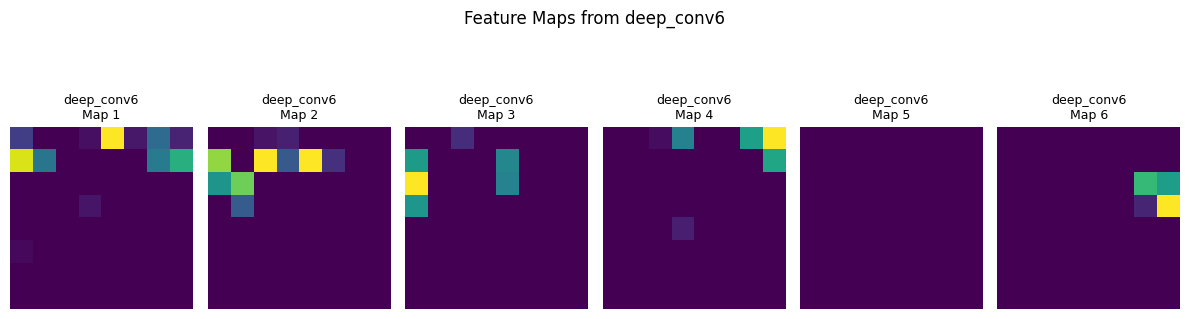

In [25]:
deep_layers_to_view = ["deep_conv1", "deep_conv3", "deep_conv6"]

deep_activations = get_feature_maps(deep_model, sample_image, deep_layers_to_view)
plot_feature_maps(deep_activations, deep_layers_to_view, max_maps=6)

### Direct Feature Comparison

A direct comparison between corresponding layers in the shallow, medium, and deep CNNs helps highlight how internal representations change as network depth increases.

The shallow CNN produces relatively simple feature maps, while the medium CNN captures more structured and refined patterns. The deep CNN generates more abstract and selective activations, focusing on the most relevant features of the input image.

This comparison clearly demonstrates how increasing network depth leads to more complex and meaningful feature representations.

In [23]:
def compare_single_feature_map_three(model1, model2, model3, image,
                                     layer1, layer2, layer3,
                                     map_index=0, cmap="viridis"):
    act1 = get_feature_maps(model1, image, [layer1])[0]
    act2 = get_feature_maps(model2, image, [layer2])[0]
    act3 = get_feature_maps(model3, image, [layer3])[0]

    if act1.ndim == 4:
        act1 = act1[0]
    if act2.ndim == 4:
        act2 = act2[0]
    if act3.ndim == 4:
        act3 = act3[0]

    map_index = min(
        map_index,
        act1.shape[-1] - 1,
        act2.shape[-1] - 1,
        act3.shape[-1] - 1
    )

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(act1[:, :, map_index], cmap=cmap)
    plt.title(f"Shallow: {layer1}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(act2[:, :, map_index], cmap=cmap)
    plt.title(f"Medium: {layer2}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(act3[:, :, map_index], cmap=cmap)
    plt.title(f"Deep: {layer3}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

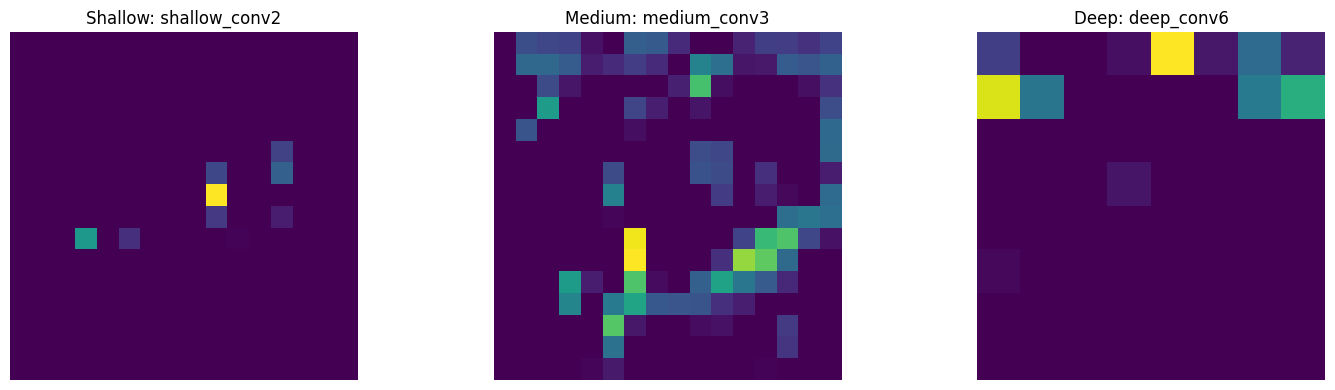

In [24]:
compare_single_feature_map_three(
    shallow_model, medium_model, deep_model,
    sample_image,
    layer1="shallow_conv2",
    layer2="medium_conv3",
    layer3="deep_conv6",
    map_index=0
)

## Discussion

The results show that increasing CNN depth improves both performance and feature learning. The shallow model captures basic patterns, while the medium and deep models learn more structured and complex representations, leading to higher accuracy.

Feature maps also demonstrate how depth affects representation. Early layers across all models detect simple features such as edges, but deeper layers in the medium and deep CNNs become more selective and abstract.

However, increasing depth introduces trade-offs. Deeper models require more computation, take longer to train, and show signs of overfitting in later epochs. In addition, very deep networks can face optimisation challenges such as vanishing gradients.

Overall, the experiment shows that deeper CNNs are more effective for complex tasks, but their benefits must be balanced against computational cost and overfitting risk.

## Conclusion

This project shows that increasing CNN depth improves both feature learning and classification performance.

The shallow model captures basic patterns such as edges and textures, while the medium and deep models learn more structured and abstract representations. This leads to improved accuracy as depth increases.

Feature map visualisations clearly demonstrate this progression from simple to more complex feature learning across the models.

Overall, the results highlight the importance of network depth, while also showing that improvements become more gradual at higher depths.

## References 

Krizhevsky, A. (2009) *Learning multiple layers of features from tiny images*. University of Toronto.  

Chollet, F. (2021) *Deep Learning with Python*. Manning Publications.  

TensorFlow Developers (2024) *TensorFlow documentation*. Available at: https://www.tensorflow.org/ (Accessed: 25 March 2026).  

CIFAR-10 Dataset (2009) Available at: https://www.cs.toronto.edu/~kriz/cifar.html (Accessed: 25 March 2026).  